In [2]:
import torch
import numpy as np

In [3]:
from load_dataset import LoadDataset
from model import MLP
from torch.utils.data import DataLoader

In [4]:
from training import Trainer
from metrics import Evaluator

In [5]:
from gradients import GradMonitor 
import matplotlib.pyplot as plt  

In [6]:
iris_path = '/home/nascj/knowledge_distillation/dataset/Iris.csv'
iris = LoadDataset(iris_path)
iris.load()
train_data, test_data = iris.split_dataset()

In [7]:
train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
test_loader = DataLoader(test_data, batch_size=32, shuffle=False)

In [8]:
config_iris_MLP = {
    'input_dim': 4,
    'in_channels': 1,   
    'output_dim': 3,     # RGB
    'fc': [5],
    'criterion':  torch.nn.CrossEntropyLoss(),
    'optimizer':  torch.optim.Adam,
    'lr': 0.001
}

In [9]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
student = MLP(config_iris_MLP).to(device)
teacher = MLP(config_iris_MLP).to(device)
trainer = Trainer(teacher, config_iris_MLP)
epochs = 1000
ptrain_old = Evaluator(teacher).accuracy(train_loader)
patience = 0
for _ in range(epochs):
    trainer.train_epoch(train_loader)
    ptrain = Evaluator(teacher).accuracy(train_loader)
    if abs(ptrain_old - ptrain) < 1e-3:  # Convergence check
        patience += 1
    else:
        patience = 0
    ptrain_old = ptrain
    if patience >= 60:  # Early stopping after 5 epochs without improvement
        print(f"Early stopping at epoch {_+1}")
        break
metrics = Evaluator(teacher)
print(metrics.accuracy(train_loader), metrics.accuracy(test_loader))
grad_teacher = GradMonitor(teacher, config_iris_MLP)
info_teacher = grad_teacher.get_gradients(train_loader)


Early stopping at epoch 320
0.9809523809523809 0.9111111111111111


In [18]:
def get_student_model(T, c, teacher, train_loader, config, max_epochs=1000):
   student = MLP(config).to(device)
   t_student = Trainer(student, config)
   ptrain = Evaluator(teacher).accuracy(train_loader)
   for k in range(max_epochs):
       t_student.train_student(teacher, train_loader, T=T, c=c)
       strain = Evaluator(student).accuracy(train_loader)
       if abs(strain - ptrain) < 0.001:  # Convergence check
           break
   return student, k

In [37]:
iris_smaller = {
    'input_dim': 4,
    'in_channels': 1,   
    'output_dim': 3,     # RGB
    'fc': [4],
    'criterion':  torch.nn.CrossEntropyLoss(),
    'optimizer':  torch.optim.Adam,
    'lr': 0.001
}

In [ ]:
estudantes = []
test_prec = [Evaluator(teacher).accuracy(test_loader)]
train_prec = [Evaluator(teacher).accuracy(train_loader)]
epochs = [320]
for t,c in zip([1,2,5,10],[0,0,0,0]):
   print(t,c)
   prof = teacher
   for i in range(300):
      student, k = get_student_model(T=t, c=c, teacher=prof, config=iris_smaller,train_loader=train_loader, max_epochs=2000)
      estudantes.append(student)
      epochs.append(k)
      test_prec.append(Evaluator(student).accuracy(test_loader))
      train_prec.append(Evaluator(student).accuracy(train_loader))
      print(f"Student {i+1} trained in {k} epochs with test accuracy: {test_prec[-1]:.4f}, train accuracy: {train_prec[-1]:.4f}")
      prof = student  # ✓ Student i+1 learns from Student i

1 0


Student 1 trained in 461 epochs with test accuracy: 0.8222, train accuracy: 0.9810
Student 2 trained in 288 epochs with test accuracy: 0.8667, train accuracy: 0.9810


Text(0.5, 1.0, 'Train accuracy of Students')

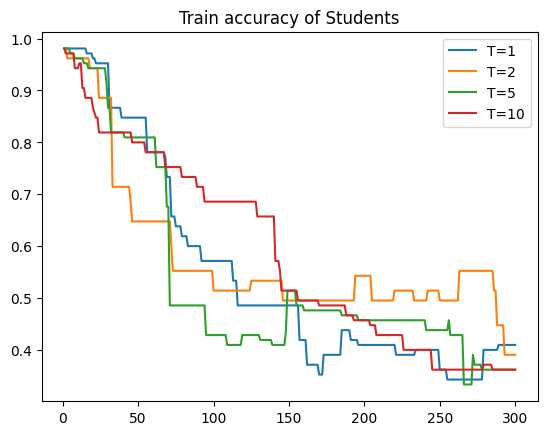

In [33]:
for i in range(4):
    plt.plot(list(range(1, 301)), train_prec[i*300+1:(i+1)*300+1], label=f'T={ [1,2,5,10][i] }')
                 # plt.plot(list(range(1, 300)), test_prec[i*300+1:(i+1)*300+1], label=f'T={ [1,2,5,10][i] }, c={ [0,0,0,0][i] }')

plt.legend()
plt.title('Train accuracy of Students')

In [35]:
import pandas as pd

In [36]:
import pandas as pd
import numpy as np

T_values = [1, 2, 5, 10]

data = {}

for i, T in enumerate(T_values):
    data[f"train_T={T}"] = train_prec[i*300:(i+1)*300]
    data[f"test_T={T}"]  = test_prec[i*300:(i+1)*300]

df = pd.DataFrame(data)
df.insert(0, "step", np.arange(1, 301))

df.to_csv("train_test_prec.csv", index=False)

Text(0.5, 1.0, 'Teste accuracy of Students')

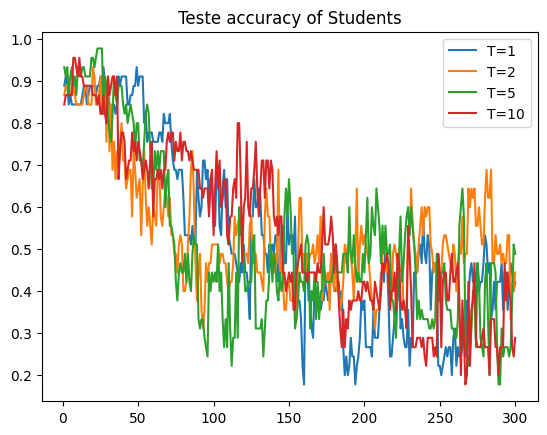

In [32]:
for i in range(4):
    plt.plot(list(range(1, 301)), test_prec[i*300+1:(i+1)*300+1], label=f'T={ [1,2,5,10][i] }')
                 # plt.plot(list(range(1, 300)), test_prec[i*300+1:(i+1)*300+1], label=f'T={ [1,2,5,10][i] }, c={ [0,0,0,0][i] }')

plt.legend()
plt.title('Teste accuracy of Students')

In [10]:
teacher_grad_all = {}
student_grad_all = {}
output_student_all = {}
output_teacher_all = {}
pred_student_all = {}
pred_teacher_all = {}
for params in st_models:
    grad_student = GradMonitor(st_models[params], config_iris_MLP)
    info_student = grad_student.get_gradients(train_loader) 
    teacher_grad = []
    student_grad = []
    output_teacher = []
    output_student = []
    pred_teacher = []
    pred_student = []
    for i in range(len(info_student)):
        teacher_grad.append(info_teacher[i]['grads']['layers.fc1.weight'])
        student_grad.append(info_student[i]['grads']['layers.fc1.weight'])
        output_student.append(info_student[i]['grads']['layers.fc2.weight'])
        output_teacher.append(info_teacher[i]['grads']['layers.fc2.weight'])
        pred_student.append(info_student[i]['pred_labels'])
        pred_teacher.append(info_teacher[i]['pred_labels'])
    teacher_grad = torch.cat(teacher_grad, dim=0)
    student_grad = torch.cat(student_grad, dim=0)
    output_teacher = torch.cat(output_teacher, dim=0)
    output_student = torch.cat(output_student, dim=0)
    pred_teacher = torch.cat(pred_teacher, dim=0)
    pred_student = torch.cat(pred_student, dim=0)  
    torder = np.argsort(pred_teacher.cpu().numpy())
    sorder = np.argsort(pred_student.cpu().numpy())
    teacher_grad_sorted = teacher_grad[torder]
    student_grad_sorted = student_grad[sorder]
    output_student_sorted = output_student[sorder]
    output_teacher_sorted = output_teacher[torder] 
    pred_student_all[params] = pred_student
    pred_teacher_all[params] = pred_teacher
    teacher_grad_all[params] = teacher_grad_sorted
    student_grad_all[params] = student_grad_sorted
    output_student_all[params] = output_student_sorted
    output_teacher_all[params] = output_teacher_sorted  

In [11]:
from pruning_utils import compute_similarity_matrix

In [12]:
all_teacher_similarity = {}
all_student_similarity = {}
all_output_teacher_similarity = {}
all_output_student_similarity = {}
for params in student_grad_all:
    teacher_similarity = compute_similarity_matrix(teacher_grad_all[params])
    student_similarity = compute_similarity_matrix(student_grad_all[params])
    output_teacher_similarity = compute_similarity_matrix(output_teacher_all[params])
    output_student_similarity = compute_similarity_matrix(output_student_all[params])
    all_teacher_similarity[params] = teacher_similarity
    all_student_similarity[params] = student_similarity
    all_output_teacher_similarity[params] = output_teacher_similarity
    all_output_student_similarity[params] = output_student_similarity